# Rapport - Profiling sémantique des joueurs PMind (`lowN30`)


<style>
table.dataframe { border-collapse: collapse; width: 100%; font-size: 13px; margin: 10px 0 22px 0; }
table.dataframe th { background: #17324d; color: white; padding: 7px; text-align: left; }
table.dataframe td { border-bottom: 1px solid #ddd; padding: 6px; vertical-align: top; }
.note { background: #f3f7fb; border-left: 5px solid #3b82f6; padding: 12px; margin: 14px 0; }
.warn { background: #fff7ed; border-left: 5px solid #f97316; padding: 12px; margin: 14px 0; }
.ok { background: #f0fdf4; border-left: 5px solid #22c55e; padding: 12px; margin: 14px 0; }
</style>


**Objectif.** Construire des profils de joueurs lisibles à partir de leurs comportements en partie, sans réduire le style à l'Elo.



## 0. Features utilisées

Avant de construire les profils, les données coup par coup sont agrégées au niveau joueur. Chaque joueur est donc décrit par des features comportementales calculées sur ses 30 parties.

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Bloc</th>
      <th>Features utilisées</th>
      <th>Rôle</th>
      <th>Dimensions liées</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Temps / rythme</td>
      <td>time_mean_s, time_median_s, time_p90_s, good_fast_rate</td>
      <td>Mesurer si le joueur joue vite ou lentement par rapport aux joueurs de niveau similaire.</td>
      <td>tempo_rapide</td>
    </tr>
    <tr>
      <td>Pression temporelle</td>
      <td>low_clock_rate, error_low_clock_rate, blunder_low_clock_rate, time_on_error_vs_mean</td>
      <td>Mesurer si le joueur se retrouve souvent avec peu de temps et s'il commet des erreurs dans ces moments.</td>
      <td>pression_temps</td>
    </tr>
    <tr>
      <td>Activité tactique</td>
      <td>rate_capture, rate_check, critical_rate, rate_promotion</td>
      <td>Décrire le caractère actif ou tactique du jeu : captures, échecs et positions critiques.</td>
      <td>agressivite_tactique</td>
    </tr>
    <tr>
      <td>Risque et erreurs</td>
      <td>rate_blunder, rate_mistake, loss_p90, loss_drift_end_vs_start</td>
      <td>Mesurer la tendance à produire des erreurs importantes ou des pertes fortes en centipions.</td>
      <td>risque_erreurs</td>
    </tr>
    <tr>
      <td>Phases de jeu</td>
      <td>loss_opening, loss_middlegame, loss_endgame, error_endgame, blunder_endgame, endgame_minus_opening_loss, endgame_minus_middlegame_error</td>
      <td>Comparer la qualité du joueur entre ouverture, milieu de jeu et finale.</td>
      <td>fragilite_finale</td>
    </tr>
    <tr>
      <td>Stabilité</td>
      <td>loss_mean_std, rate_blunder_std, target_score_std, loss_iqr</td>
      <td>Mesurer la régularité du joueur d'une partie à l'autre.</td>
      <td>instabilite</td>
    </tr>
    <tr>
      <td>Conversion des positions favorables</td>
      <td>loss_when_winning, blunder_when_winning, winning_minus_equal_loss, loss_when_equal</td>
      <td>Mesurer si le joueur garde sa précision quand il est mieux ou gagnant.</td>
      <td>conversion_faible</td>
    </tr>
  </tbody>
</table>

Ces features ne sont pas utilisées comme un simple bloc brut. Elles sont regroupées en dimensions de style, puis corrigées par rapport au niveau estimé du joueur afin de comparer un joueur à des joueurs de niveau similaire.


## 0.1. Résumé du calcul des scores de style

Les scores de style sont calculés en plusieurs étapes :

```text
features brutes
→ normalisation robuste
→ combinaison en dimensions de style
→ correction par l'Elo prédit
→ comparaison locale avec joueurs proches
→ profil sémantique
```

1. Chaque feature est d'abord mise sur une échelle comparable avec une normalisation robuste :

```text
z = (valeur - médiane) / IQR
```

où `IQR = Q3 - Q1`.

2. Plusieurs features normalisées sont ensuite combinées pour former une dimension de style. Par exemple :

```text
tempo_rapide =
moyenne(
    - time_mean_s,
    - time_median_s,
    - time_p90_s,
    + good_fast_rate
)
```

Les signes négatifs indiquent qu'un temps plus faible correspond à un joueur plus rapide.

3. Le score est ensuite corrigé par rapport à l'Elo prédit :

```text
score_résiduel = score_observé - score_attendu_pour_ce_niveau
```

Cela permet de dire qu'un joueur est rapide, risqué ou instable **par rapport aux joueurs de niveau similaire**, et non simplement parce qu'il est plus fort ou plus faible.

4. Enfin, le joueur est comparé aux joueurs les plus proches en Elo prédit dans la même cadence :

```text
score_local = (score_joueur - médiane_des_voisins) / IQR_des_voisins
```

Les dimensions les plus fortes deviennent le profil final. Exemple :

```text
style_tempo_rapide = +1.3
style_agressivite_tactique = +0.9
style_instabilite = +1.1

→ rapide + agressif + instable
```


## 1. Pourquoi ne pas utiliser un clustering classique ?

Les essais de clustering géométrique donnaient des scores de silhouette faibles. Cela signifie que les joueurs ne se séparent pas naturellement en blocs très nets. Ce résultat est cohérent avec le problème étudié : aux échecs, deux joueurs de même niveau peuvent avoir des comportements différents, et un même joueur peut combiner plusieurs traits.

La solution retenue est donc de construire des **scores de style continus**, puis de les transformer en **profils sémantiques interprétables**.

```text
parties du joueur
→ features comportementales
→ Elo prédit comme contexte
→ comparaison avec les joueurs proches en Elo
→ scores de style
→ profil sémantique
```


## 2. Données utilisées

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Cadence</th>
      <th>Joueurs</th>
      <th>Elo_moyen</th>
      <th>Profils</th>
      <th>Profil_mixte_pct</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>blitz</td>
      <td>700</td>
      <td>1672.43</td>
      <td>22</td>
      <td>2.29</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>700</td>
      <td>1681.58</td>
      <td>23</td>
      <td>1.71</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>486</td>
      <td>1582.69</td>
      <td>19</td>
      <td>2.26</td>
    </tr>
  </tbody>
</table>

Chaque joueur est représenté par 30 parties dans sa cadence. Le corpus rapid est plus petit car seulement 486 joueurs respectaient les critères de collecte.


## 3. Dimensions de style

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Dimension</th>
      <th>Score positif</th>
      <th>Score négatif</th>
      <th>Sens</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>tempo_rapide</td>
      <td>rapide</td>
      <td>lent</td>
      <td>Gestion du rythme de jeu et du temps moyen par coup.</td>
    </tr>
    <tr>
      <td>agressivite_tactique</td>
      <td>agressif</td>
      <td>calme/positionnel</td>
      <td>Tendance à jouer des coups tactiques : captures, échecs, positions critiques.</td>
    </tr>
    <tr>
      <td>risque_erreurs</td>
      <td>risqué</td>
      <td>propre</td>
      <td>Propension à produire des erreurs, fautes et pertes fortes en centipions.</td>
    </tr>
    <tr>
      <td>pression_temps</td>
      <td>sous pression temps</td>
      <td>confortable au temps</td>
      <td>Fragilité quand l'horloge devient basse.</td>
    </tr>
    <tr>
      <td>fragilite_finale</td>
      <td>fragile en finale</td>
      <td>stable en finale</td>
      <td>Dégradation relative en finale par rapport aux autres phases.</td>
    </tr>
    <tr>
      <td>instabilite</td>
      <td>instable</td>
      <td>régulier</td>
      <td>Variabilité des performances d'une partie à l'autre.</td>
    </tr>
    <tr>
      <td>conversion_faible</td>
      <td>convertit mal</td>
      <td>bon convertisseur</td>
      <td>Difficulté à convertir les positions favorables.</td>
    </tr>
  </tbody>
</table>

Les scores sont corrigés par rapport à l'Elo prédit et calculés localement par cadence. Cela évite que les profils deviennent simplement des groupes de niveau.


## 4. Construction des profils sémantiques

Pour chaque joueur, on garde les traits dont le score est le plus dominant. Les combinaisons fréquentes sont conservées telles quelles, par exemple :

```text
instable + risqué
sous pression temps + agressif
lent + sous pression temps
régulier + propre
```

Les combinaisons trop rares sont simplifiées vers un ou deux traits dominants. Si aucun trait n'est assez net, le joueur est placé dans `profil mixte / rare`.


## 5. Résultats globaux

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Cadence</th>
      <th>Nb profils</th>
      <th>% joueurs interprétables</th>
      <th>Alignement nom/profil</th>
      <th>Stabilité</th>
      <th>Ratio cohésion</th>
      <th>Eta² profil→Elo</th>
      <th>Corr. style/Elo</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>blitz</td>
      <td>22</td>
      <td>97.7</td>
      <td>0.931</td>
      <td>0.720</td>
      <td>0.648</td>
      <td>0.043</td>
      <td>0.016</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>23</td>
      <td>98.3</td>
      <td>0.939</td>
      <td>0.718</td>
      <td>0.637</td>
      <td>0.038</td>
      <td>0.019</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>19</td>
      <td>97.7</td>
      <td>0.953</td>
      <td>0.756</td>
      <td>0.651</td>
      <td>0.051</td>
      <td>0.022</td>
    </tr>
  </tbody>
</table>

### Visualisation des métriques

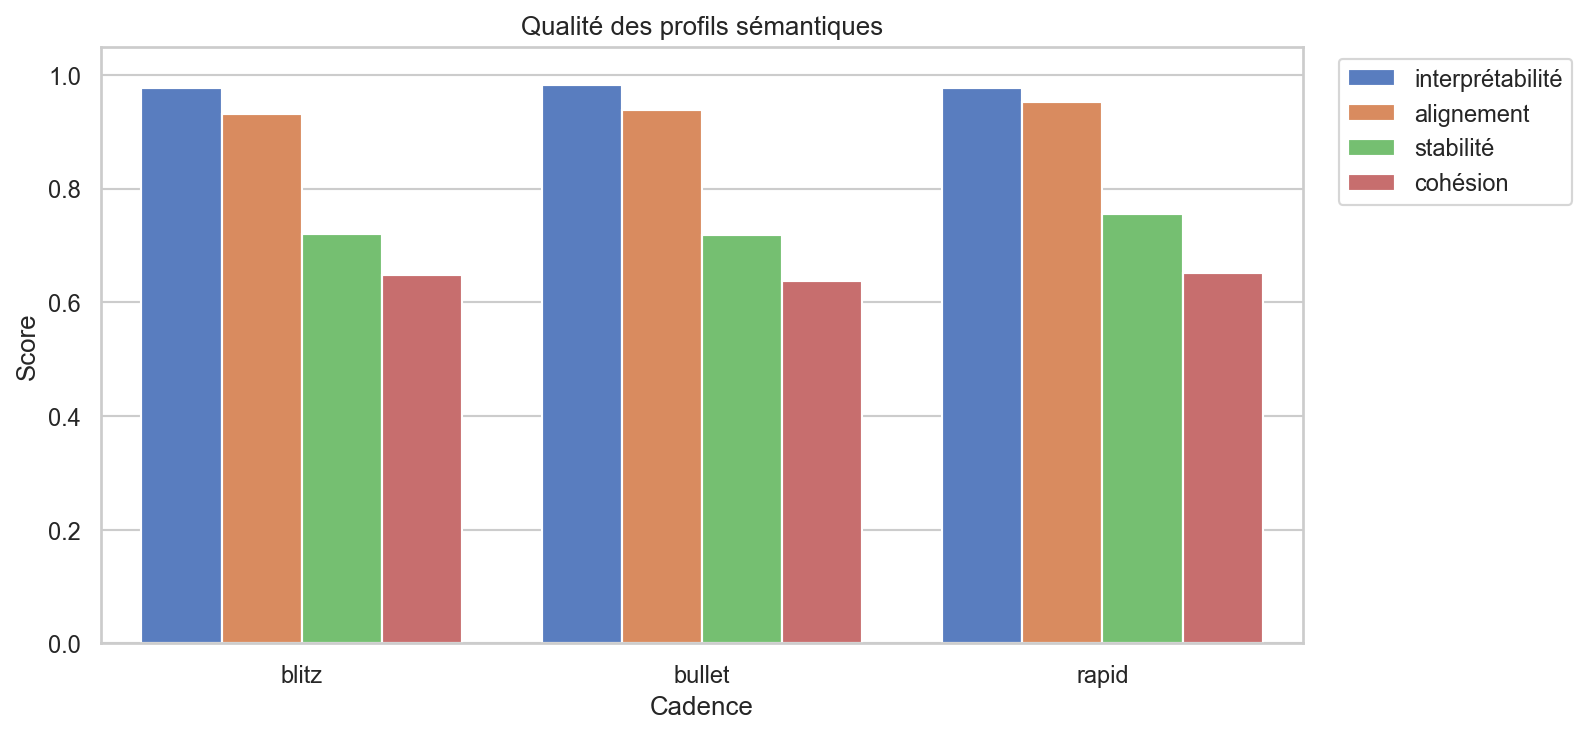

## 6. Réponse aux quatre questions

### Question 1 - Est-ce que le profil est interprétable ?

Oui. L'alignement entre le nom du profil et les scores internes est élevé :

- blitz : 0.931
- bullet : 0.939
- rapid : 0.953

Cela signifie que les joueurs nommés `agressif`, `lent`, `instable`, etc. ont effectivement des scores dominants dans ces dimensions.

### Question 2 - Est-ce qu'il est stable quand on change légèrement les données ?

Oui, avec une stabilité correcte. Après perturbation contrôlée des scores de style, le même profil est conservé environ 72% à 76% du temps selon la cadence.

### Question 3 - Est-ce que les joueurs du même profil ont des scores proches ?

Oui. Le ratio de cohésion est inférieur à 1 dans les trois cadences, ce qui signifie que les joueurs d'un même profil sont plus proches entre eux que deux joueurs pris au hasard.

### Question 4 - Est-ce que le profil apporte une information différente de l'Elo ?

Oui. L'Eta² entre profils et Elo reste faible, entre 0.038 et 0.051. Les corrélations moyennes entre scores de style et Elo prédit sont également très faibles, autour de 0.02.

- **blitz** : 97.7% de joueurs dans des profils interprétables, stabilité 0.720, cohésion 0.648, Eta² profil→Elo 0.043.
- **bullet** : 98.3% de joueurs dans des profils interprétables, stabilité 0.718, cohésion 0.637, Eta² profil→Elo 0.038.
- **rapid** : 97.7% de joueurs dans des profils interprétables, stabilité 0.756, cohésion 0.651, Eta² profil→Elo 0.051.

## 7. Profils les plus fréquents

- **blitz** : lent (64), fragile en finale (59), convertit mal (58), sous pression temps (54), régulier (52), agressif (50).
- **bullet** : fragile en finale (75), convertit mal (61), sous pression temps (57), rapide (46), stable en finale (46), propre (45).
- **rapid** : sous pression temps (49), agressif (42), fragile en finale (42), lent (38), convertit mal (36), régulier (36).

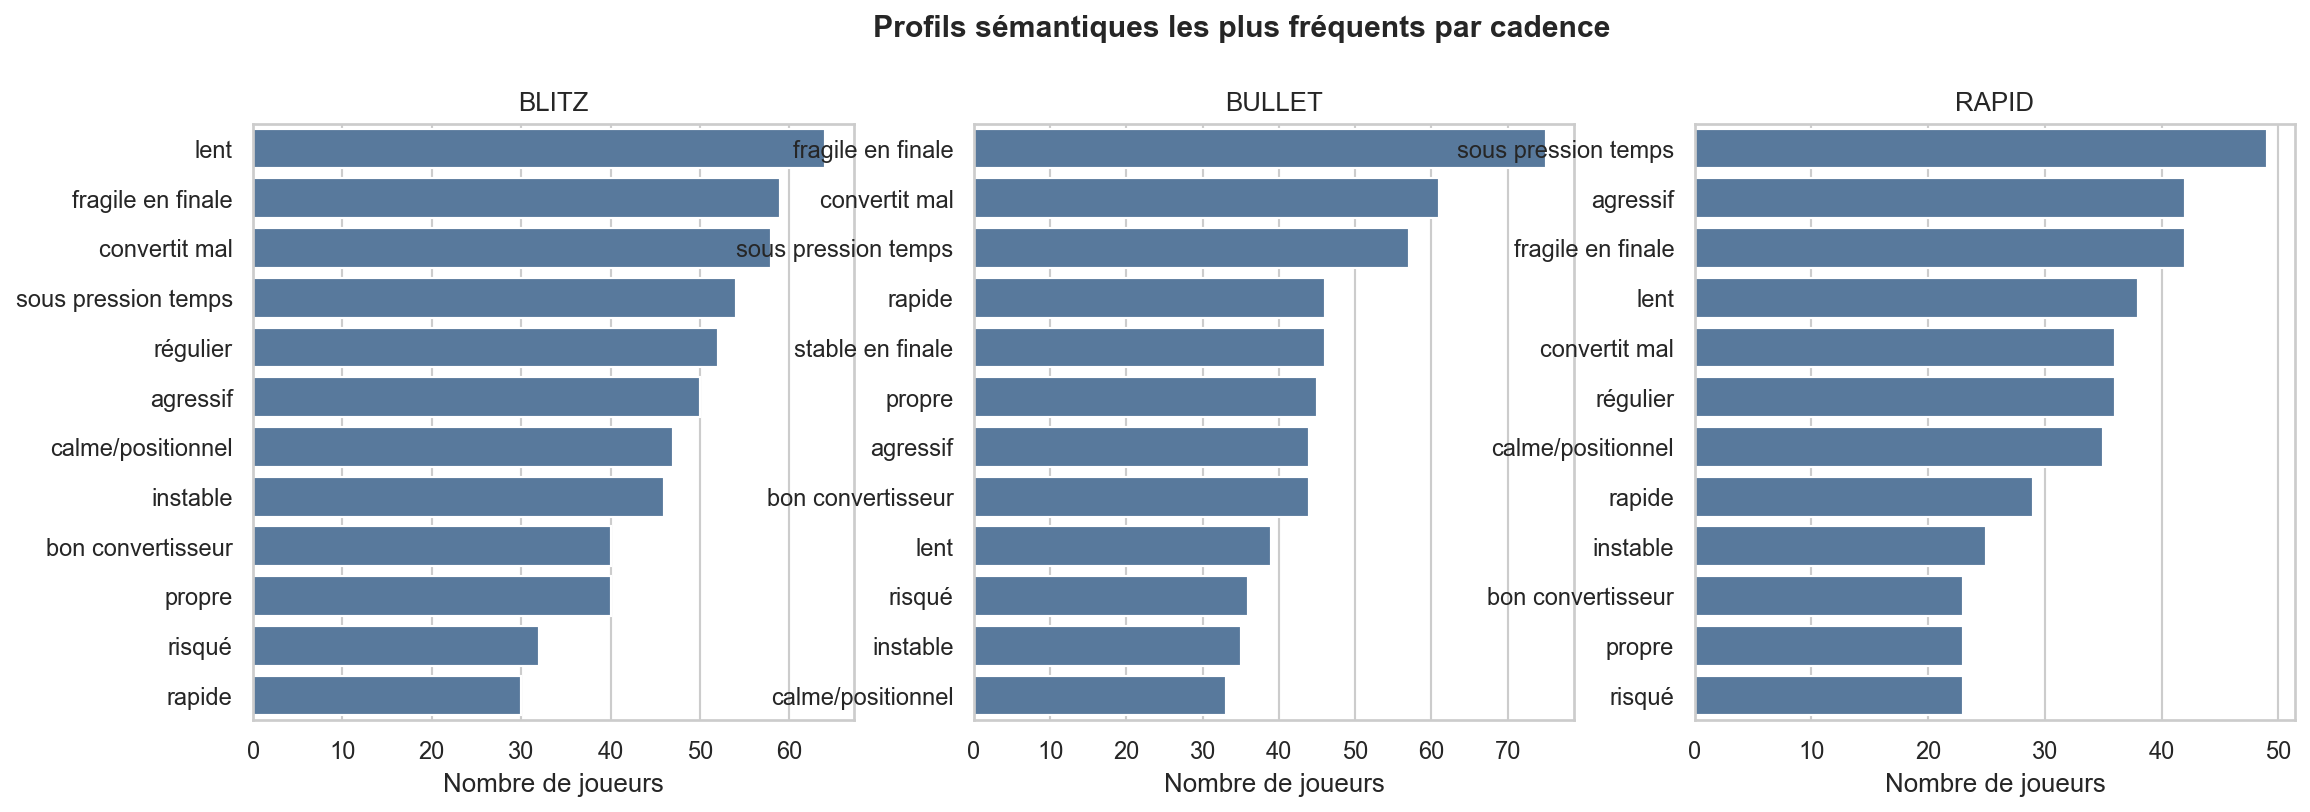

## 8. Relation avec l'Elo

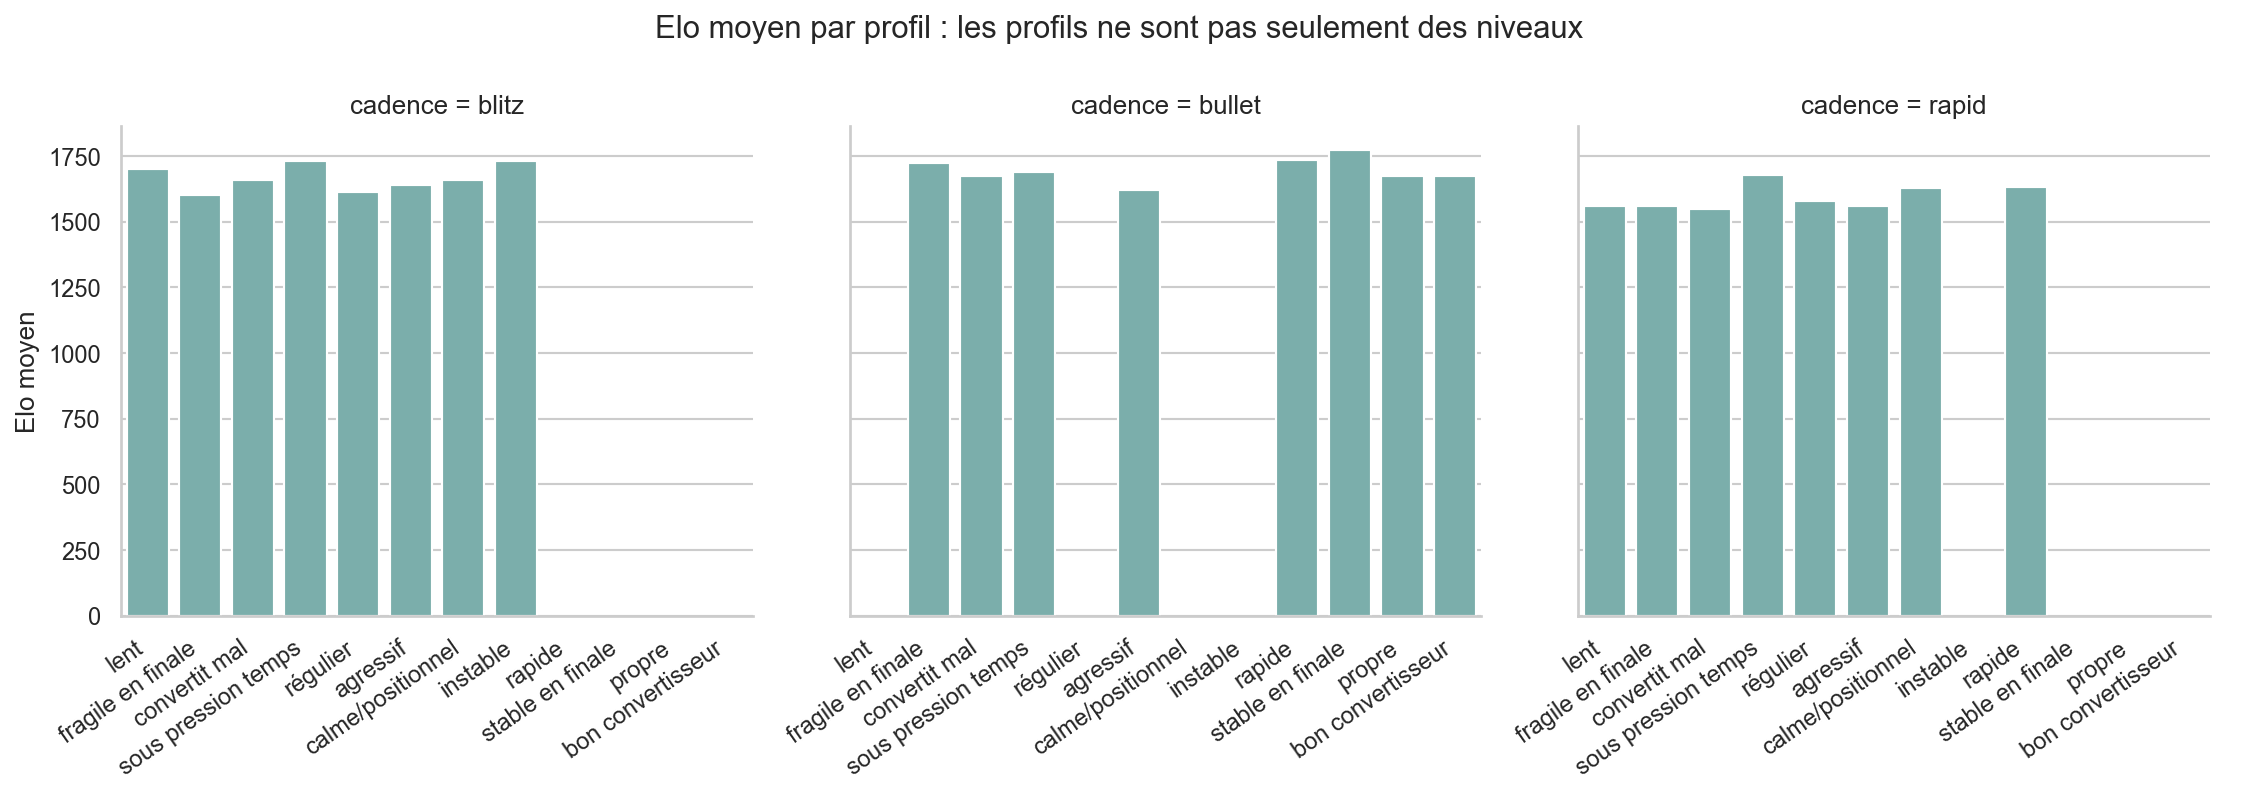

## 9. Lecture des profils - BULLET

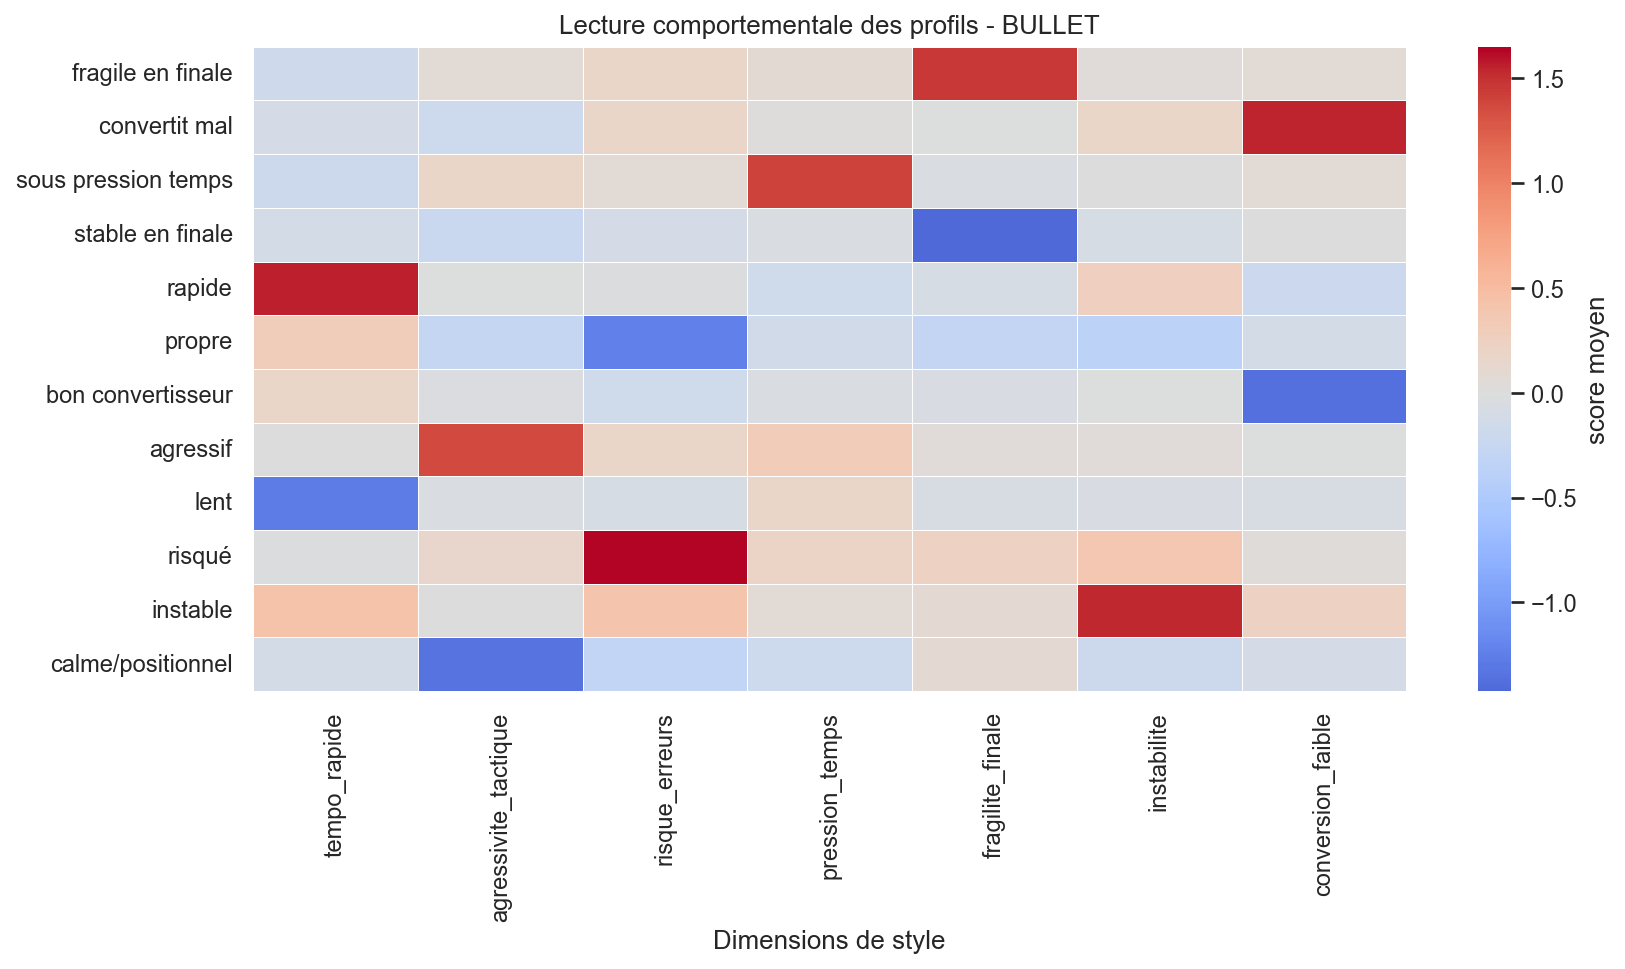

## 9. Lecture des profils - BLITZ

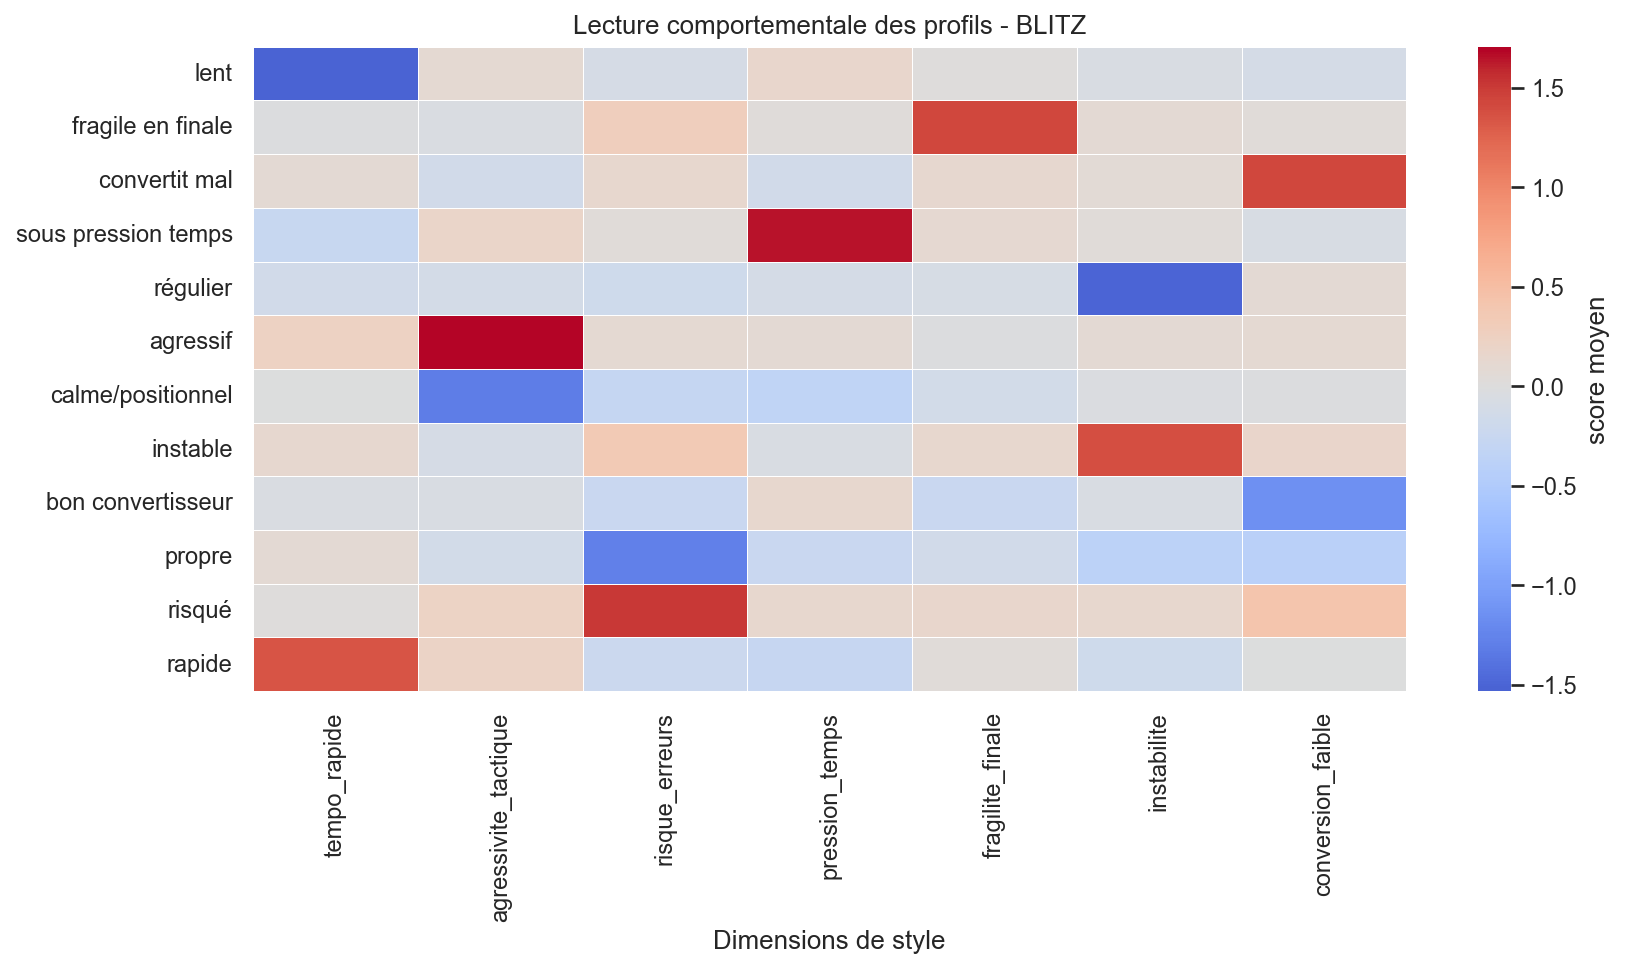

## 9. Lecture des profils - RAPID

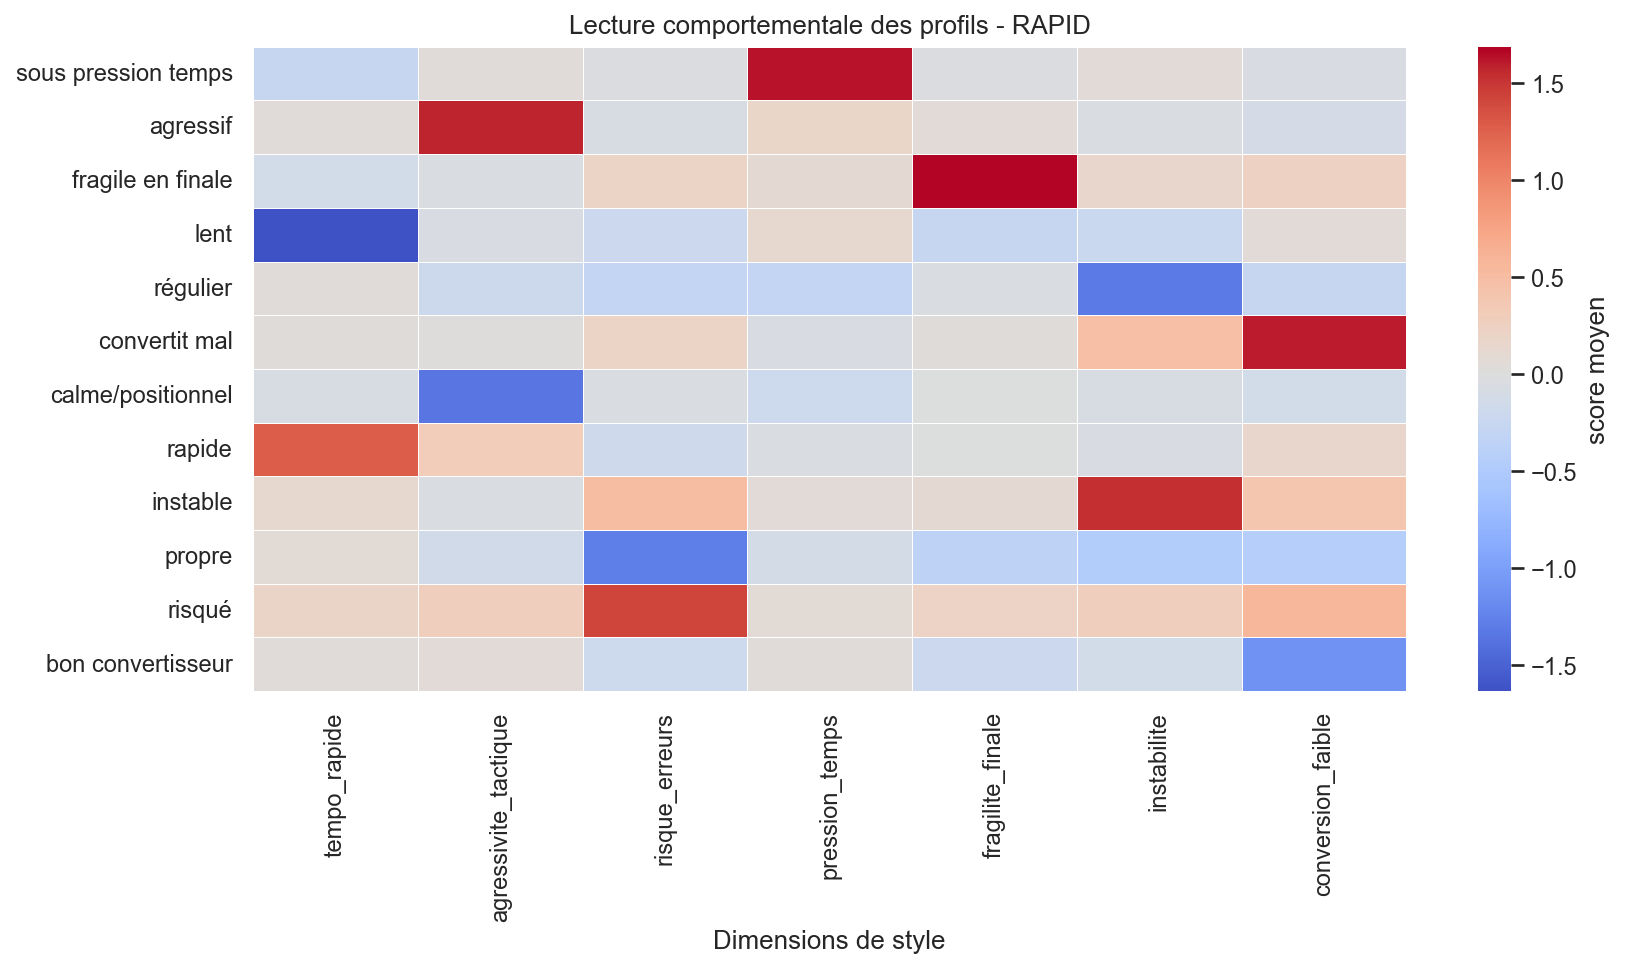

## 10. Détails d'interprétabilité

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>cadence</th>
      <th>semantic_profile</th>
      <th>n_players</th>
      <th>n_tags</th>
      <th>mean_style_strength</th>
      <th>mean_tag_score</th>
      <th>tag_alignment_rate</th>
      <th>top_dimensions_moyennes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>blitz</td>
      <td>lent</td>
      <td>64</td>
      <td>1</td>
      <td>1.533</td>
      <td>1.533</td>
      <td>0.938</td>
      <td>tempo_rapide=-1.53; pression_temps=+0.16; conversion_faible=-0.12</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>fragile en finale</td>
      <td>59</td>
      <td>1</td>
      <td>1.421</td>
      <td>1.421</td>
      <td>0.966</td>
      <td>fragilite_finale=+1.42; risque_erreurs=+0.28; instabilite=+0.08</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>convertit mal</td>
      <td>58</td>
      <td>1</td>
      <td>1.439</td>
      <td>1.439</td>
      <td>0.897</td>
      <td>conversion_faible=+1.44; pression_temps=-0.15; agressivite_tactique=-0.15</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>sous pression temps</td>
      <td>54</td>
      <td>1</td>
      <td>1.644</td>
      <td>1.644</td>
      <td>0.926</td>
      <td>pression_temps=+1.64; tempo_rapide=-0.26; agressivite_tactique=+0.18</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>régulier</td>
      <td>52</td>
      <td>1</td>
      <td>1.496</td>
      <td>1.496</td>
      <td>0.904</td>
      <td>instabilite=-1.50; risque_erreurs=-0.18; tempo_rapide=-0.14</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>agressif</td>
      <td>50</td>
      <td>1</td>
      <td>1.706</td>
      <td>1.706</td>
      <td>0.980</td>
      <td>agressivite_tactique=+1.71; tempo_rapide=+0.23; risque_erreurs=+0.10</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>calme/positionnel</td>
      <td>47</td>
      <td>1</td>
      <td>1.306</td>
      <td>1.306</td>
      <td>0.851</td>
      <td>agressivite_tactique=-1.31; pression_temps=-0.33; risque_erreurs=-0.29</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>instable</td>
      <td>46</td>
      <td>1</td>
      <td>1.382</td>
      <td>1.382</td>
      <td>0.891</td>
      <td>instabilite=+1.38; risque_erreurs=+0.34; conversion_faible=+0.17</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>fragile en finale</td>
      <td>75</td>
      <td>1</td>
      <td>1.454</td>
      <td>1.454</td>
      <td>0.867</td>
      <td>fragilite_finale=+1.45; risque_erreurs=+0.19; tempo_rapide=-0.17</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>convertit mal</td>
      <td>61</td>
      <td>1</td>
      <td>1.555</td>
      <td>1.555</td>
      <td>0.967</td>
      <td>conversion_faible=+1.55; instabilite=+0.18; agressivite_tactique=-0.18</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>sous pression temps</td>
      <td>57</td>
      <td>1</td>
      <td>1.407</td>
      <td>1.407</td>
      <td>0.912</td>
      <td>pression_temps=+1.41; tempo_rapide=-0.21; agressivite_tactique=+0.18</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>rapide</td>
      <td>46</td>
      <td>1</td>
      <td>1.558</td>
      <td>1.558</td>
      <td>0.935</td>
      <td>tempo_rapide=+1.56; instabilite=+0.26; conversion_faible=-0.21</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>stable en finale</td>
      <td>46</td>
      <td>1</td>
      <td>1.424</td>
      <td>1.424</td>
      <td>0.978</td>
      <td>fragilite_finale=-1.42; agressivite_tactique=-0.23; tempo_rapide=-0.13</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>propre</td>
      <td>45</td>
      <td>1</td>
      <td>1.234</td>
      <td>1.234</td>
      <td>0.844</td>
      <td>risque_erreurs=-1.23; instabilite=-0.37; fragilite_finale=-0.29</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>agressif</td>
      <td>44</td>
      <td>1</td>
      <td>1.369</td>
      <td>1.369</td>
      <td>0.909</td>
      <td>agressivite_tactique=+1.37; pression_temps=+0.32; risque_erreurs=+0.17</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>bon convertisseur</td>
      <td>44</td>
      <td>1</td>
      <td>1.370</td>
      <td>1.370</td>
      <td>0.955</td>
      <td>conversion_faible=-1.37; tempo_rapide=+0.17; risque_erreurs=-0.15</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>sous pression temps</td>
      <td>49</td>
      <td>1</td>
      <td>1.629</td>
      <td>1.629</td>
      <td>1.000</td>
      <td>pression_temps=+1.63; tempo_rapide=-0.27; instabilite=+0.06</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>agressif</td>
      <td>42</td>
      <td>1</td>
      <td>1.578</td>
      <td>1.578</td>
      <td>0.952</td>
      <td>agressivite_tactique=+1.58; pression_temps=+0.17; conversion_faible=-0.11</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>fragile en finale</td>
      <td>42</td>
      <td>1</td>
      <td>1.686</td>
      <td>1.686</td>
      <td>0.929</td>
      <td>fragilite_finale=+1.69; conversion_faible=+0.22; risque_erreurs=+0.20</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>lent</td>
      <td>38</td>
      <td>1</td>
      <td>1.635</td>
      <td>1.635</td>
      <td>0.974</td>
      <td>tempo_rapide=-1.63; fragilite_finale=-0.27; instabilite=-0.23</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>convertit mal</td>
      <td>36</td>
      <td>1</td>
      <td>1.597</td>
      <td>1.597</td>
      <td>0.917</td>
      <td>conversion_faible=+1.60; instabilite=+0.48; risque_erreurs=+0.20</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>régulier</td>
      <td>36</td>
      <td>1</td>
      <td>1.314</td>
      <td>1.314</td>
      <td>0.889</td>
      <td>instabilite=-1.31; risque_erreurs=-0.30; pression_temps=-0.29</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>calme/positionnel</td>
      <td>35</td>
      <td>1</td>
      <td>1.356</td>
      <td>1.356</td>
      <td>1.000</td>
      <td>agressivite_tactique=-1.36; pression_temps=-0.18; conversion_faible=-0.14</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>rapide</td>
      <td>29</td>
      <td>1</td>
      <td>1.278</td>
      <td>1.278</td>
      <td>0.897</td>
      <td>tempo_rapide=+1.28; agressivite_tactique=+0.30; risque_erreurs=-0.17</td>
    </tr>
  </tbody>
</table>

## 11. Profils les plus stables

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>semantic_profile</th>
      <th>n_players</th>
      <th>mean_stability</th>
      <th>p10_stability</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>stable en finale</td>
      <td>97</td>
      <td>0.804</td>
      <td>0.753</td>
    </tr>
    <tr>
      <td>fragile en finale</td>
      <td>176</td>
      <td>0.793</td>
      <td>0.744</td>
    </tr>
    <tr>
      <td>convertit mal</td>
      <td>155</td>
      <td>0.788</td>
      <td>0.729</td>
    </tr>
    <tr>
      <td>calme/positionnel</td>
      <td>115</td>
      <td>0.787</td>
      <td>0.739</td>
    </tr>
    <tr>
      <td>agressif</td>
      <td>136</td>
      <td>0.784</td>
      <td>0.728</td>
    </tr>
    <tr>
      <td>lent</td>
      <td>141</td>
      <td>0.775</td>
      <td>0.723</td>
    </tr>
    <tr>
      <td>bon convertisseur</td>
      <td>107</td>
      <td>0.766</td>
      <td>0.710</td>
    </tr>
    <tr>
      <td>risqué</td>
      <td>91</td>
      <td>0.763</td>
      <td>0.703</td>
    </tr>
    <tr>
      <td>rapide</td>
      <td>105</td>
      <td>0.762</td>
      <td>0.695</td>
    </tr>
    <tr>
      <td>sous pression temps</td>
      <td>160</td>
      <td>0.760</td>
      <td>0.706</td>
    </tr>
    <tr>
      <td>instable + risqué</td>
      <td>14</td>
      <td>0.752</td>
      <td>0.643</td>
    </tr>
    <tr>
      <td>régulier</td>
      <td>117</td>
      <td>0.747</td>
      <td>0.692</td>
    </tr>
    <tr>
      <td>instable</td>
      <td>106</td>
      <td>0.727</td>
      <td>0.659</td>
    </tr>
    <tr>
      <td>propre</td>
      <td>108</td>
      <td>0.702</td>
      <td>0.638</td>
    </tr>
    <tr>
      <td>confortable au temps</td>
      <td>50</td>
      <td>0.700</td>
      <td>0.620</td>
    </tr>
  </tbody>
</table>

## 12. Profils les plus cohérents

<table class="dataframe dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>cadence</th>
      <th>semantic_profile</th>
      <th>n_players</th>
      <th>intra_distance</th>
      <th>global_distance</th>
      <th>cohesion_ratio</th>
      <th>nearest_other_center_distance</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>blitz</td>
      <td>profil mixte / rare</td>
      <td>16</td>
      <td>0.882</td>
      <td>2.954</td>
      <td>0.299</td>
      <td>1.315</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>bon convertisseur + régulier</td>
      <td>9</td>
      <td>1.436</td>
      <td>2.954</td>
      <td>0.486</td>
      <td>1.437</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>agressif + instable</td>
      <td>10</td>
      <td>1.553</td>
      <td>2.954</td>
      <td>0.526</td>
      <td>1.131</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>sous pression temps + instable</td>
      <td>9</td>
      <td>1.574</td>
      <td>2.954</td>
      <td>0.533</td>
      <td>1.249</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>risqué + instable</td>
      <td>8</td>
      <td>1.612</td>
      <td>2.954</td>
      <td>0.546</td>
      <td>1.166</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>lent + calme/positionnel</td>
      <td>10</td>
      <td>1.761</td>
      <td>2.954</td>
      <td>0.596</td>
      <td>1.253</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>régulier + propre</td>
      <td>9</td>
      <td>1.773</td>
      <td>2.954</td>
      <td>0.600</td>
      <td>1.460</td>
    </tr>
    <tr>
      <td>blitz</td>
      <td>bon convertisseur</td>
      <td>40</td>
      <td>1.793</td>
      <td>2.954</td>
      <td>0.607</td>
      <td>1.334</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>profil mixte / rare</td>
      <td>12</td>
      <td>0.961</td>
      <td>2.933</td>
      <td>0.328</td>
      <td>0.990</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>sous pression temps + lent</td>
      <td>8</td>
      <td>1.148</td>
      <td>2.933</td>
      <td>0.391</td>
      <td>0.900</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>rapide + propre</td>
      <td>9</td>
      <td>1.454</td>
      <td>2.933</td>
      <td>0.496</td>
      <td>1.333</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>confortable au temps</td>
      <td>21</td>
      <td>1.478</td>
      <td>2.933</td>
      <td>0.504</td>
      <td>0.990</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>convertit mal + rapide</td>
      <td>9</td>
      <td>1.561</td>
      <td>2.933</td>
      <td>0.532</td>
      <td>1.179</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>instable + risqué</td>
      <td>14</td>
      <td>1.680</td>
      <td>2.933</td>
      <td>0.573</td>
      <td>0.968</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>agressif + risqué</td>
      <td>8</td>
      <td>1.768</td>
      <td>2.933</td>
      <td>0.603</td>
      <td>1.402</td>
    </tr>
    <tr>
      <td>bullet</td>
      <td>régulier + propre</td>
      <td>9</td>
      <td>1.781</td>
      <td>2.933</td>
      <td>0.607</td>
      <td>1.459</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>profil mixte / rare</td>
      <td>11</td>
      <td>0.915</td>
      <td>3.016</td>
      <td>0.303</td>
      <td>1.101</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>fragile en finale + risqué</td>
      <td>8</td>
      <td>1.661</td>
      <td>3.016</td>
      <td>0.551</td>
      <td>1.161</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>bon convertisseur</td>
      <td>23</td>
      <td>1.712</td>
      <td>3.016</td>
      <td>0.568</td>
      <td>1.237</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>propre</td>
      <td>23</td>
      <td>1.789</td>
      <td>3.016</td>
      <td>0.593</td>
      <td>1.351</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>risqué + fragile en finale</td>
      <td>8</td>
      <td>1.803</td>
      <td>3.016</td>
      <td>0.598</td>
      <td>1.161</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>rapide</td>
      <td>29</td>
      <td>1.812</td>
      <td>3.016</td>
      <td>0.601</td>
      <td>1.239</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>confortable au temps</td>
      <td>15</td>
      <td>1.819</td>
      <td>3.016</td>
      <td>0.603</td>
      <td>1.101</td>
    </tr>
    <tr>
      <td>rapid</td>
      <td>régulier</td>
      <td>36</td>
      <td>1.823</td>
      <td>3.016</td>
      <td>0.605</td>
      <td>1.364</td>
    </tr>
  </tbody>
</table>

## 13. Conclusion pour le rapport

Les résultats montrent que le style de jeu ne se structure pas en clusters naturels fortement séparés. En revanche, la représentation par profils sémantiques est exploitable : elle est lisible, relativement stable, cohérente à l'intérieur des groupes, et largement indépendante de l'Elo.

Cette approche est donc plus adaptée au projet PMind qu'un clustering classique. Elle permet de décrire un joueur non seulement par son niveau estimé, mais aussi par sa manière de jouer : gestion du temps, agressivité, stabilité, risque d'erreur, fragilité en finale et capacité de conversion.

Formulation possible :

```text
L'Elo sert de contexte de comparaison, tandis que les profils sémantiques décrivent le comportement du joueur relativement à des joueurs de niveau similaire.
```


## 14. Limites

- Les profils ne doivent pas être interprétés comme des classes naturelles parfaitement séparées.
- Les combinaisons rares sont moins stables que les profils simples.
- La qualité dépend des features disponibles, notamment les pertes en centipions, le temps et les phases de jeu.
- Une validation future pourrait mesurer la stabilité quand on passe de 30 parties à 10 ou 5 parties.


## Annexe - Code de consultation

In [3]:
from pathlib import Path
import pandas as pd

ROOT = Path("results") / "player_semantic_profiles"
profiles = pd.read_csv(ROOT / "player_semantic_profiles_lowN30.csv")
diagnostic = pd.read_csv(ROOT / "semantic_profile_diagnostic_lowN30.csv")
counts = pd.read_csv(ROOT / "semantic_profile_counts_lowN30.csv")

display(diagnostic)
display(counts.groupby("source_cadence").head(10))


,cadence,n_profiles,pct_players_in_interpretable_profiles,mean_tag_alignment_rate,mean_stability_same_profile,mean_cohesion_ratio,eta2_elo,mean_abs_corr_style_vs_pred_elo
0,blitz,22,97.714286,0.931011,0.720226,0.648470,0.043251,0.015915
1,bullet,23,98.285714,0.938673,0.718405,0.636846,0.038246,0.019283
2,rapid,19,97.736626,0.952541,0.755658,0.651097,0.050535,0.021627


,source_cadence,semantic_profile,n_players
0,blitz,lent,64
1,blitz,fragile en finale,59
2,blitz,convertit mal,58
3,blitz,sous pression temps,54
4,blitz,régulier,52
5,blitz,agressif,50
6,blitz,calme/positionnel,47
7,blitz,instable,46
8,blitz,bon convertisseur,40
9,blitz,propre,40


In [4]:
style_cols = [
    "style_tempo_rapide",
    "style_agressivite_tactique",
    "style_risque_erreurs",
    "style_pression_temps",
    "style_fragilite_finale",
    "style_instabilite",
    "style_conversion_faible",
]

def show_player_profile(name: str, cadence: str | None = None):
    q = profiles.copy()
    if cadence is not None:
        q = q[q["source_cadence"].eq(cadence)]
    mask = q["raw_username"].astype(str).str.lower().str.contains(name.lower(), regex=False)
    cols = [
        "source_cadence", "raw_username", "elo", "elo_pred",
        "elo_context_band_100", "semantic_profile",
        "semantic_vector_top3", "style_top_dimensions",
    ] + style_cols
    return q.loc[mask, cols].sort_values(["source_cadence", "elo_pred"])

# Exemple :
# show_player_profile("nom_du_joueur", cadence="blitz")
profiles[[
    "source_cadence", "raw_username", "elo", "elo_pred",
    "semantic_profile", "semantic_vector_top3", "style_top_dimensions",
]].sample(10, random_state=42)


,source_cadence,raw_username,elo,elo_pred,semantic_profile,semantic_vector_top3,style_top_dimensions
307,bullet,player_006,1736,1574.061884,fragile en finale,fragile en finale + confortable au temps + cal...,fragilite_finale=+1.37; pression_temps=-1.08; ...
382,bullet,player_005,1725,1506.293625,bon convertisseur,bon convertisseur + lent + régulier,conversion_faible=-1.80; tempo_rapide=-1.23; i...
462,bullet,player_009,1839,1820.374529,calme/positionnel,calme/positionnel + bon convertisseur,agressivite_tactique=-1.63; conversion_faible=...
1741,rapid,player_013,1752,1581.983686,risqué + instable,risqué + instable + convertit mal,risque_erreurs=+3.00; instabilite=+1.39; conve...
917,blitz,player_012,1476,1462.500075,bon convertisseur + régulier,bon convertisseur + régulier + confortable au ...,conversion_faible=-2.23; instabilite=-1.84; pr...
1053,blitz,player_003,1645,1591.730596,risqué + instable,risqué + instable,risque_erreurs=+1.18; instabilite=+0.88; press...
270,bullet,player_008,1436,1743.966978,calme/positionnel,calme/positionnel + fragile en finale,agressivite_tactique=-1.00; fragilite_finale=+...
596,bullet,player_002,2013,1871.071417,sous pression temps,sous pression temps,pression_temps=+1.28; agressivite_tactique=+0....
1075,blitz,player_014,1685,1764.268729,rapide,rapide,tempo_rapide=+1.25; fragilite_finale=-0.70; ag...
411,bullet,player_010,1641,1785.011646,régulier,régulier + calme/positionnel + propre,instabilite=-1.09; agressivite_tactique=-0.89;...
